Accuracy: 0.7707364815267923
              precision    recall  f1-score   support

           0       0.83      0.82      0.82      1524
           1       0.71      0.82      0.76      1763
           2       0.85      0.58      0.69       800

    accuracy                           0.77      4087
   macro avg       0.79      0.74      0.76      4087
weighted avg       0.78      0.77      0.77      4087



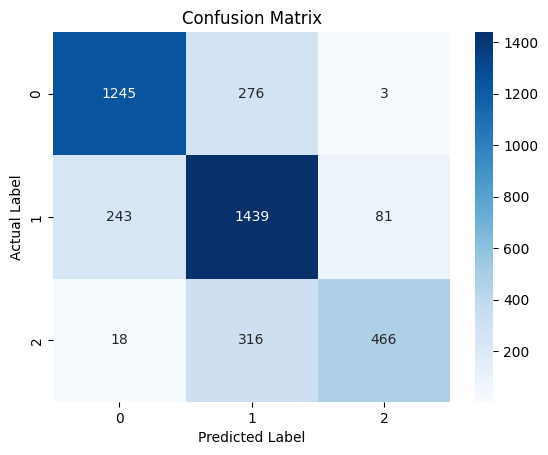

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

data = pd.read_csv('housing.csv')

data = data.dropna()

bins = [0, 150000, 300000, np.inf]
labels = [0, 1, 2]
data['price_category'] = pd.cut(data['median_house_value'], bins=bins, labels=labels)

X = data.drop(['median_house_value', 'price_category'], axis=1)
y = data['price_category']

X = pd.get_dummies(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = SVC(kernel='rbf')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters found: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
Best Score found: 0.7999513151227324
Accuracy with best model: 0.8032786885245902
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1524
           1       0.76      0.82      0.78      1763
           2       0.83      0.70      0.76       800

    accuracy                           0.80      4087
   macro avg       0.81      0.79      0.80      4087
weighted avg       0.81      0.80      0.80      4087



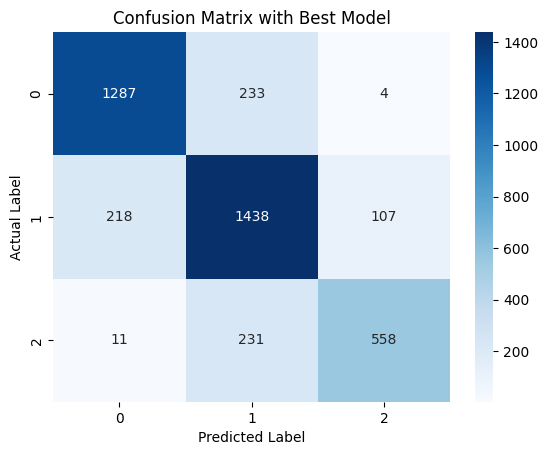

In [5]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for SVC
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(SVC(), param_grid, refit=True, verbose=2, cv=3, n_jobs=-1)

# Fit the GridSearchCV object to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best Parameters found:", grid_search.best_params_)
print("Best Score found:", grid_search.best_score_)

# Get the best model
best_model = grid_search.best_estimator_

# Make predictions with the best model
y_pred_best = best_model.predict(X_test)

# Evaluate the best model
acc_best = accuracy_score(y_test, y_pred_best)
print("Accuracy with best model:", acc_best)
print(classification_report(y_test, y_pred_best))

cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix with Best Model")
plt.show()